# 03 - SHAP

Original cells 83-88. Cells 85 and 89 were empty and are deleted.

**Scope decision: report only.** These are global feature-importance figures
for a write-up -- a dev artifact. `serve.py` returns a probability and a
decision, not per-patient attributions.

If per-patient explanations are ever wanted from the API, the explainer
becomes a *second versioned artifact*: cell 86 below proves the values are
exactly `beta_j * (z_ij - zbar_j)`, so all that needs saving alongside the
model is the coefficient vector and the training column means -- both already
inside the fitted pipeline. Worth doing for a clinical decision-support
framing; not worth doing just because SHAP is in the notebook.

In [ ]:
# --- make src/ importable ------------------------------------------------
import sys
from pathlib import Path

_here = Path.cwd()
for _p in (_here, *_here.parents):
    if (_p / "src" / "disease_pred").is_dir():
        sys.path.insert(0, str(_p / "src"))
        PROJECT = _p
        break
else:
    raise RuntimeError("could not locate src/disease_pred above %s" % _here)
print("project root:", PROJECT)

import numpy as np
import pandas as pd
import shap

from disease_pred.data import prepare
from disease_pred.evaluate import load_artifacts
from disease_pred.features import output_names

# The fitted pipeline off disk -- run `python -m disease_pred.train` first.
final_model, spec = load_artifacts()
THRESHOLD = spec['threshold']

prepared = prepare()
X_train, X_test = prepared['X_train'], prepared['X_test']
y_train, y_test = prepared['y_train'], prepared['y_test']


p_test = final_model.predict_proba(X_test)[:, 1]

print('threshold:', THRESHOLD, '| design columns:', len(feature_names))

project root: e:\AI_ML\Prac\Logistic Regression\disease prediction project
threshold: 0.2 | design columns: 16


Background dataset has 688 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=688 when initializing the masker.


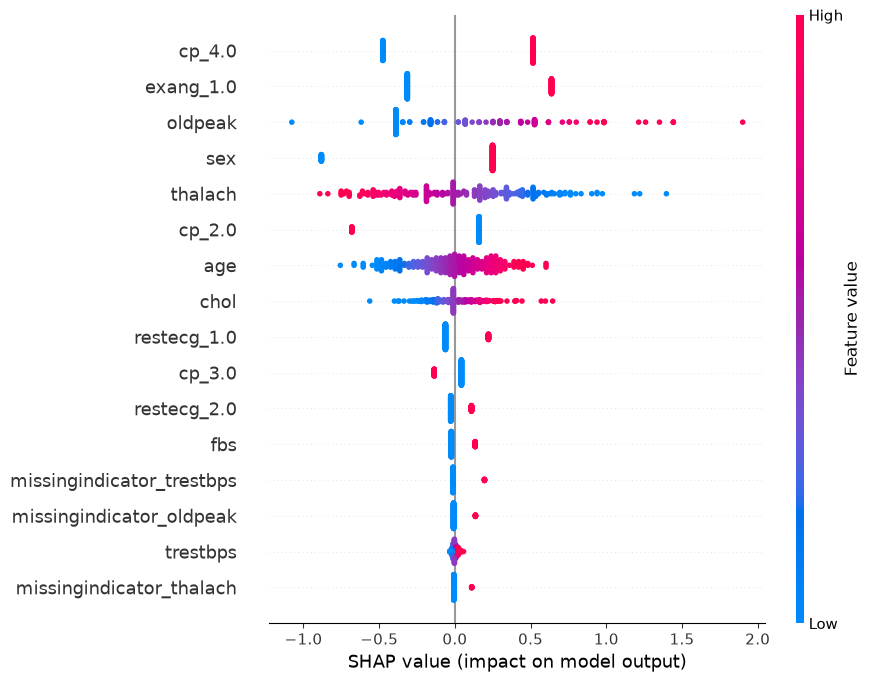

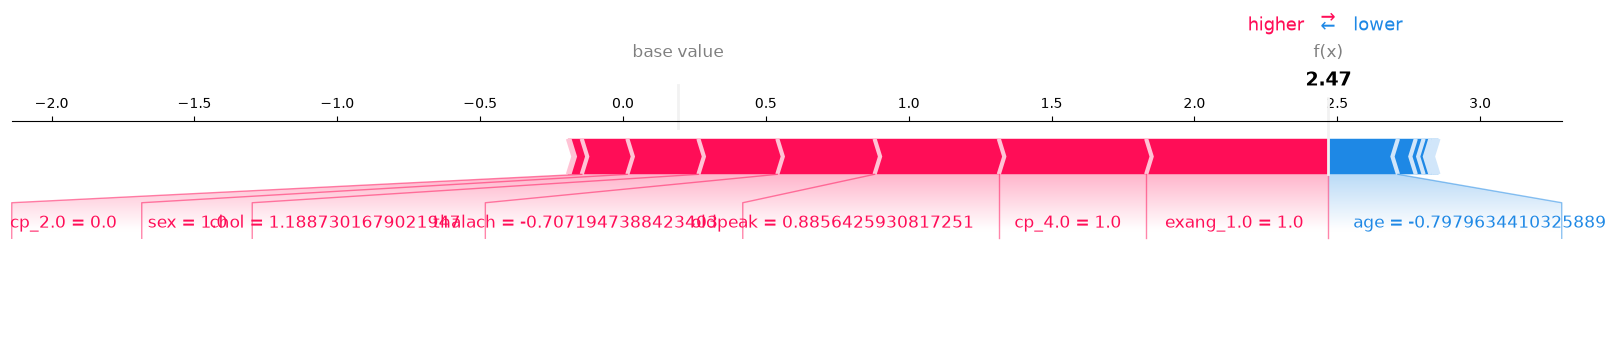

In [ ]:

pre= final_model.named_steps['pre']
clf= final_model.named_steps['clf']
feature_names = output_names(pre)
Z_tr = pd.DataFrame(pre.transform(X_train), columns=feature_names, index=X_train.index)
Z_te = pd.DataFrame(pre.transform(X_test),  columns=feature_names, index=X_test.index)
explainer = shap.LinearExplainer(clf, Z_tr)   # background = train
sv = explainer(Z_te)  


shap.plots.beeswarm(sv, max_display=20)

i = 0                                         # position of the test row to explain
shap.plots.force(sv[i], matplotlib=True)

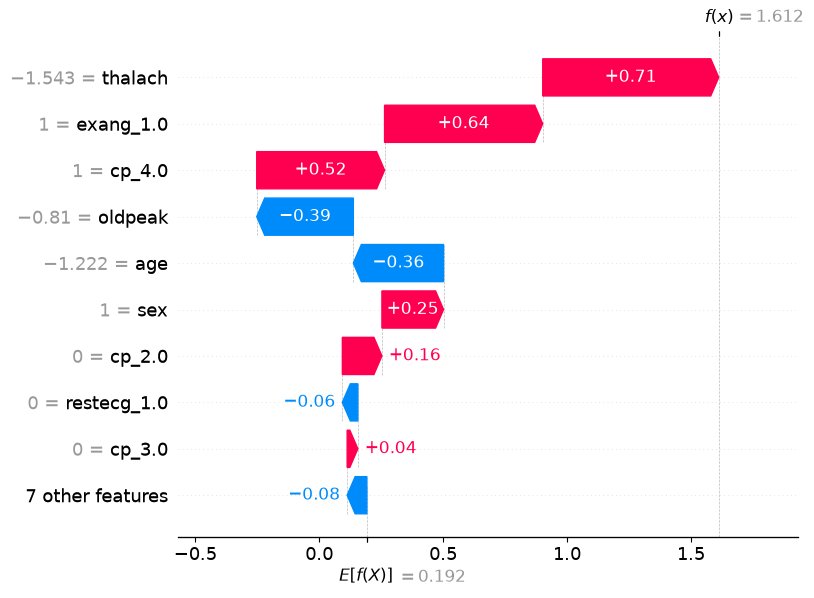

In [8]:
shap.plots.waterfall(sv[i+2])